# Catalogo orbital Space-Track - Validacion y estadisticas descriptivas

Este notebook inspecciona la descarga local del catalogo historico de
elementos orbitales (`gp_history`) almacenada en `data/gp_history/` como
Parquet particionado por anio (`year=YYYY`).

Objetivos:

1. **Validar** la integridad de la descarga (esquema consistente, cobertura
   temporal sin huecos, checksum de las TLE).
2. **Describir** el catalogo: total de registros, objetos distintos,
   distribucion por tipo de objeto, paises, regimenes orbitales (LEO/GEO/MEO/HEO)
   y su evolucion anual.
3. Mostrar **muestras reales** de cuatro eras representativas (1960, 1980,
   2010, 2024).

Toda la informacion se calcula leyendo el catalogo **por partes proyectadas**
(columnas seleccionadas) para mantener el uso de RAM acotado aunque el
conjunto completo pese varios GB en disco.


## 0. Configuracion e imports

In [1]:
from __future__ import annotations

import glob
import os
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import pandas as pd

# matplotlib en modo inline para notebooks
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
except Exception:
    pass

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Raiz del repo: buscamos data/gp_history subiendo desde el directorio
# de trabajo del kernel (cambia segun donde se lance jupyter).
def _find_data_dir() -> Path:
    for root in [Path.cwd(), *Path.cwd().resolve().parents]:
        candidate = root / "data" / "gp_history"
        if candidate.exists():
            return candidate
    raise AssertionError(
        "No existe data/gp_history - ejecuta primero scripts/fetch_gp_history.py"
    )

DATA_DIR = _find_data_dir()

ALL_FILES = sorted(glob.glob(str(DATA_DIR / "year=*" / "part-*.parquet")))
ALL_YEARS = sorted(
    int(f.split("year=")[1].split(os.sep)[0]) for f in ALL_FILES
)
print(f"Archivos parte: {len(ALL_FILES)}")
print(f"Rango de anios: {min(ALL_YEARS)} - {max(ALL_YEARS)}")


Archivos parte: 455
Rango de anios: 1960 - 2026


## 1. Tamano del catalogo: filas y archivos por anio

In [2]:
# Contar filas por archivo usando SOLO metadata (muy rapido, no carga datos).
rows_per_file = {}
for f in ALL_FILES:
    year = int(f.split("year=")[1].split(os.sep)[0])
    n = pq.read_metadata(f).num_rows
    rows_per_file[f] = (year, n)

by_year = defaultdict(int)
files_year = defaultdict(int)
for year, n in rows_per_file.values():
    by_year[year] += n
    files_year[year] += 1

total_rows = sum(by_year.values())
print(f"Total de registros (element sets) en el catalogo: {total_rows:,}")
print(f"Total de archivos Parquet: {len(ALL_FILES)}")
print(f"Anios con datos: {len(by_year)}")

df_rows = pd.DataFrame(
    {
        "anio": sorted(by_year),
        "filas": [by_year[y] for y in sorted(by_year)],
        "archivos": [files_year[y] for y in sorted(by_year)],
    }
)
df_rows["crecimiento_vs_anterior"] = df_rows["filas"].pct_change() * 100
df_rows.head(15)


Total de registros (element sets) en el catalogo: 67,197,568
Total de archivos Parquet: 455
Anios con datos: 67


,anio,filas,archivos,crecimiento_vs_anterior
0,1960,737,2,NaN
1,1961,2459,1,233.649932
2,1962,3879,1,57.747052
3,1963,4422,1,13.998453
4,1964,6835,2,54.568069
5,1965,13497,1,97.468910
6,1966,18283,1,35.459732
7,1967,37218,1,103.566154
8,1968,31772,2,-14.632705
9,1969,45753,1,44.004155


## 2. Estadisticas globales

Se leen de cada archivo solo las columnas necesarias y se acumulan
incrementalmente en memoria, de modo que no hay que cargar el catalogo entero.


In [3]:
# Columnas que realmente necesitamos para las agregaciones globales.
COLS_AGREG = [
    "NORAD_CAT_ID", "OBJECT_TYPE", "COUNTRY_CODE", "RCS_SIZE",
    "PERIAPSIS", "APOAPSIS", "EPOCH",
]

norad_all: set[int] = set()
obj_type_count = Counter()
country_count = Counter()
rcs_count = Counter()
periapsis: list[float] = []

# Para la clasificacion orbital por anio tambien guardamos contadores.
orbital_by_year: dict[int, Counter] = defaultdict(Counter)

for f in ALL_FILES:
    year = int(f.split("year=")[1].split(os.sep)[0])
    t = pq.read_table(f, columns=COLS_AGREG)
    df = t.to_pandas()

    norad_all.update(df["NORAD_CAT_ID"].dropna().astype("int64"))
    obj_type_count.update(df["OBJECT_TYPE"].fillna("N/A").astype(str))
    country_count.update(df["COUNTRY_CODE"].fillna("N/A").astype(str))
    rcs_count.update(df["RCS_SIZE"].fillna("N/A").astype(str))
    periapsis.extend(df["PERIAPSIS"].dropna().tolist())

    # Clasificar cada registro en un regimen orbital simple.
    per = df["PERIAPSIS"].fillna(np.nan)
    apo = df["APOAPSIS"].fillna(np.nan)
    mask_unknown = per.isna() | apo.isna()
    regime = pd.Series("UNKNOWN", index=df.index)
    regime[~mask_unknown & (per <= 2000.0) & (apo <= 2000.0)] = "LEO"
    regime[~mask_unknown & (per > 2000.0) & (apo < 35000.0)] = "MEO"
    regime[~mask_unknown & (per >= 35000.0) & (apo <= 41000.0)] = "GEO"
    regime[~mask_unknown & (
        (apo >= 35000.0) & (per < 35000.0)  # HEO / GTO / transferencia
    )] = "HEO"
    orbital_by_year[year].update(regime.tolist())

print(f"Objetos distintos (NORAD_CAT_ID unicos): {len(norad_all):,}")
print(f"Filas con periapsis valida: {len(periapsis):,}")
per = np.array(periapsis)
print(
    "Periapsis: p50={:.0f} km, p5={:.0f} km, p95={:.0f} km".format(
        np.percentile(per, 50), np.percentile(per, 5), np.percentile(per, 95)
    )
)


Objetos distintos (NORAD_CAT_ID unicos): 63,761
Filas con periapsis valida: 67,197,536


Periapsis: p50=733 km, p5=359 km, p95=35729 km


In [4]:
print("=== Tipo de objeto ===")
print(pd.Series(obj_type_count).sort_values(ascending=False).to_string())

print("\n=== Regimen orbital (toda la historia) ===")
tot_regime = Counter()
for c in orbital_by_year.values():
    tot_regime.update(c)
print(pd.Series(tot_regime).sort_values(ascending=False).to_string())

print("\n=== Tamano de seccion transversal radar (RCS) ===")
print(pd.Series(rcs_count).sort_values(ascending=False).to_string())


=== Tipo de objeto ===
DEBRIS         29957792
PAYLOAD        28040259
ROCKET BODY     6985725
TBA             1167724
UNKNOWN         1046036
N/A                  32

=== Regimen orbital (toda la historia) ===
LEO        55504199
UNKNOWN     4415759
GEO         3868942
HEO         2009039
MEO         1399629

=== Tamano de seccion transversal radar (RCS) ===
LARGE     27189039
SMALL     25360026
MEDIUM    12898259
           1750212
N/A             32


In [5]:
print("=== Top 15 paises / organizaciones operadoras ===")
top15_country = pd.Series(country_count).sort_values(ascending=False).head(15)
print(top15_country.to_string())


=== Top 15 paises / organizaciones operadoras ===
US      27364424
CIS     19833075
PRC      9967147
FR       1545044
UK       1132015
         1068132
JPN       878381
IND       649618
TBD       544694
ESA       320852
GLOB      271526
ITSO      268628
CA        237421
GER       223789
ORB       199219


## 3. Estadisticas descriptivas por anio

In [6]:
# Por anio: filas, objetos distintos y tipo de objeto mas frecuente.
year_agg = []
for year in df_rows["anio"]:
    files_y = [f for f in ALL_FILES if f.split("year=")[1].split(os.sep)[0] == str(year)]
    norad_y: set[int] = set()
    types_y = Counter()
    for f in files_y:
        t = pq.read_table(f, columns=["NORAD_CAT_ID", "OBJECT_TYPE"])
        d = t.to_pandas()
        norad_y.update(d["NORAD_CAT_ID"].dropna().astype("int64"))
        types_y.update(d["OBJECT_TYPE"].fillna("N/A").astype(str))
    year_agg.append(
        {
            "anio": year,
            "objetos_distintos": len(norad_y),
            "tipo_dominante": types_y.most_common(1)[0][0],
            "filas_tipo_dominante": types_y.most_common(1)[0][1],
            "pct_tipo_dominante": 100 * types_y.most_common(1)[0][1] / by_year[year],
        }
    )

df_year = pd.DataFrame(year_agg).set_index("anio")
df_year["filas"] = df_year.index.map(by_year)
df_year = df_year[["filas", "objetos_distintos", "tipo_dominante",
                    "filas_tipo_dominante", "pct_tipo_dominante"]]
df_year


,filas,objetos_distintos,tipo_dominante,filas_tipo_dominante,pct_tipo_dominante
anio,,,,,
1960,737,51,TBA,439,59.565807
1961,2459,169,TBA,1093,44.448963
1962,3879,390,TBA,1845,47.563805
1963,4422,442,TBA,2430,54.952510
1964,6835,593,TBA,3352,49.041697
...,...,...,...,...,...
2022,6214115,27760,PAYLOAD,2866864,46.134711
2023,6248806,28420,PAYLOAD,3384344,54.159851
2024,6355932,29814,PAYLOAD,3738023,58.811564


In [7]:
# 10 objetos con mas registros (mas tiempo/snapshot observado).
obj_elements = Counter()
for f in ALL_FILES:
    t = pq.read_table(f, columns=["NORAD_CAT_ID", "OBJECT_NAME"])
    d = t.to_pandas()
    sub = d.dropna(subset=["NORAD_CAT_ID"])
    for cid in sub["NORAD_CAT_ID"].astype("int64"):
        obj_elements[cid] += 1

print("=== Top 10 objetos por numero de registros en el catalogo ===")
for cid, cnt in obj_elements.most_common(10):
    print(f"  NORAD {cid:>6}: {cnt:,}")


=== Top 10 objetos por numero de registros en el catalogo ===
  NORAD   6073: 10,742
  NORAD  25544: 10,347
  NORAD   2389: 7,181
  NORAD   2150: 7,166
  NORAD   4221: 7,151
  NORAD  28051: 7,026
  NORAD    831: 6,930
  NORAD  29505: 6,929
  NORAD   1616: 6,896
  NORAD    750: 6,891


## 4. Regimen orbital por anio (LEO / MEO / GEO / HEO)

In [8]:
df_orbit = pd.DataFrame(orbital_by_year).T.fillna(0).astype("int64")
df_orbit.index.name = "anio"
cols = ["LEO", "MEO", "GEO", "HEO", "UNKNOWN"]
for c in cols:
    if c not in df_orbit.columns:
        df_orbit[c] = 0
df_orbit = df_orbit[cols]
df_orbit.head(12)


,LEO,MEO,GEO,HEO,UNKNOWN
anio,,,,,
1960,619,0,0,0,118
1961,2036,27,0,3,393
1962,3566,94,0,1,218
1963,3713,107,2,15,585
1964,5727,153,21,170,764
1965,11540,353,13,342,1249
1966,15817,708,8,166,1584
1967,31247,1701,21,391,3858
1968,26710,1396,33,460,3173


In [9]:
# Participacion relativa de cada regimen sobre el total de filas del anio.
df_orbit_share = df_orbit.div(df_orbit.sum(axis=1), axis=0) * 100
df_orbit_share.round(1).iloc[[0, 5, 12, 20, 30, 40, 50, -1]]


,LEO,MEO,GEO,HEO,UNKNOWN
anio,,,,,
1960,84.0,0.0,0.0,0.0,16.0
1965,85.5,2.6,0.1,2.5,9.3
1972,78.0,2.3,0.0,2.8,16.8
1980,79.9,1.6,1.3,4.8,12.5
1990,80.5,1.8,3.2,4.5,10.0
2000,70.6,3.7,5.0,6.8,13.9
2010,81.9,2.9,4.2,3.5,7.5
2026,87.8,1.3,6.1,1.7,3.1


## 5. Muestras reales por era

In [10]:
SAMPLE_COLS = [
    "EPOCH", "OBJECT_NAME", "NORAD_CAT_ID", "OBJECT_TYPE", "OBJECT_ID",
    "COUNTRY_CODE", "ECCENTRICITY", "INCLINATION", "MEAN_MOTION",
    "PERIAPSIS", "APOAPSIS", "LAUNCH_DATE", "DECAY_DATE", "RCS_SIZE", "SITE",
]

def era_sample(year: int, n: int = 3) -> pd.DataFrame:
    f = glob.glob(str(DATA_DIR / f"year={year}" / "part-*.parquet"))[0]
    df = pq.read_table(f, columns=SAMPLE_COLS).to_pandas().head(n)
    return df

for y in [1960, 1980, 2010, 2024]:
    print("=" * 100)
    print(f"ERA {y}  (objetos distintos: {df_year.loc[y, 'objetos_distintos']}, "
          f"filas: {df_year.loc[y, 'filas']:,})")
    print("=" * 100)
    print(era_sample(y).to_string(index=False))
    print()


ERA 1960  (objetos distintos: 51, filas: 737)
                           EPOCH  OBJECT_NAME  NORAD_CAT_ID OBJECT_TYPE OBJECT_ID COUNTRY_CODE  ECCENTRICITY  INCLINATION  MEAN_MOTION  PERIAPSIS  APOAPSIS LAUNCH_DATE DECAY_DATE RCS_SIZE  SITE
1960-01-01 23:52:39.359999+00:00 VANGUARD R/B            12 ROCKET BODY 1959-001B           US      0.184033      32.8999    11.087543    553.745  3680.578  1959-02-17              MEDIUM AFETR
1960-01-02 11:15:40.460256+00:00  JUNO II R/B            23 ROCKET BODY 1959-009B           US      0.036967      50.2999    14.221427    552.095  1084.148  1959-10-13 1989-07-16   MEDIUM AFETR
1960-01-02 12:02:07.334591+00:00   EXPLORER 7            22     PAYLOAD 1959-009A           US      0.036609      50.2699    14.204845    560.066  1087.376  1959-10-13              MEDIUM AFETR

ERA 1980  (objetos distintos: 4580, filas: 501,840)
                           EPOCH    OBJECT_NAME  NORAD_CAT_ID OBJECT_TYPE  OBJECT_ID COUNTRY_CODE  ECCENTRICITY  INCLINATION 

## 6. Validacion de la descarga

### 6.1 Consistencia del esquema
Todos los archivos Parquet deben exponer exactamente las mismas columnas
(41), con tipos equivalentes, salvo variacion inofensiva entre microsegundos
y milisegundos en `EPOCH`/`CREATION_DATE`.


In [11]:
REFERENCE_SCHEMA = pq.read_schema(ALL_FILES[0])
ref_names = set(map(str, REFERENCE_SCHEMA.names))
problems = []
for f in ALL_FILES:
    s = pq.read_schema(f)
    if set(map(str, s.names)) != ref_names:
        problems.append((f, "columnas distintas"))
print(f"Archivos revisados: {len(ALL_FILES)}")
print(f"Columnas por archivo: {len(ref_names)} ({len(list(REFERENCE_SCHEMA))})")
if problems:
    print("PROBLEMA de esquema:")
    for p in problems[:10]:
        print(" ", p)
else:
    print("OK: todos los archivos comparten el mismo esquema de columnas.")


Archivos revisados: 455
Columnas por archivo: 41 (41)
OK: todos los archivos comparten el mismo esquema de columnas.


### 6.2 Cobertura temporal
El catalogo debe cubrir continuamente de 1960 hasta la fecha sin anios
faltantes y sin registros fuera del rango descargado.


In [12]:
# Cobertura real (min/max EPOCH) por anio, leyendo solo esas columnas.
coverage = []
for year in df_rows["anio"]:
    files_y = [f for f in ALL_FILES if f.split("year=")[1].split(os.sep)[0] == str(year)]
    mins, maxs = [], []
    for f in files_y:
        t = pq.read_table(f, columns=["EPOCH"])
        col = t.column("EPOCH").to_pandas()
        col = pd.to_datetime(col, utc=True)
        mins.append(col.min())
        maxs.append(col.max())
    coverage.append(
        {
            "anio": year,
            "epoch_min": min(mins),
            "epoch_max": max(maxs),
        }
    )

df_cov = pd.DataFrame(coverage)
df_cov["hueco"] = df_cov["anio"].diff().shift(-1) == 1  # False = hueco
# Ghueco real: hay un anio sin datos entre dos consecutivos
gaps = df_cov["anio"].diff().dropna()
print("Huecos en la secuencia de anios:", int((gaps > 1).sum()))
missing = set(range(df_cov["anio"].min(), df_cov["anio"].max() + 1)) - set(df_cov["anio"])
print("Anios sin datos dentro del rango:", sorted(missing) or "ninguno")
df_cov.tail(5)


Huecos en la secuencia de anios: 0
Anios sin datos dentro del rango: ninguno


,anio,epoch_min,epoch_max,hueco
62,2022,2022-01-01 00:00:03.518208+00:00,2022-12-31 23:59:59.797824+00:00,True
63,2023,2023-01-01 00:00:00.999648+00:00,2023-12-31 23:58:27.539040+00:00,True
64,2024,2024-01-01 00:00:00.999648+00:00,2024-12-31 23:59:50.950464+00:00,True
65,2025,2025-01-01 00:00:00.999648+00:00,2025-12-31 23:59:57.702624+00:00,True
66,2026,2026-01-01 00:00:00.452736+00:00,2026-09-02 19:51:35.540352+00:00,False


### 6.3 Checksum de las TLE
Cada linea TLE (1 y 2) termina en un digito de verificacion modulo-10.
Regla empleada por Space-Track: digitos valen su valor, `-` vale 1,
cualquier otro caracter (letras, espacios, `.`, `+`) vale 0. El checksum debe
coincidir con el ultimo digito de la linea.

Se valida una muestra: los primeros 2000 registros de cada anio.


In [13]:
def tle_checksum(line: str) -> int:
    total = 0
    for ch in line:
        if ch.isdigit():
            total += int(ch)
        elif ch == "-":
            total += 1
        # letras, espacios, '.' y '+': contribuyen 0
    return total % 10

# Nota: la linea TLE termina en su propio digito de verificacion (69 chars).
# El checksum se calcula sobre la linea SIN ese ultimo digito.
bad = 0
checked = 0
for year in df_rows["anio"]:
    f = glob.glob(str(DATA_DIR / f"year={year}" / "part-*.parquet"))[0]
    t = pq.read_table(f, columns=["TLE_LINE1", "TLE_LINE2"]).to_pandas()
    t = t.head(2000).dropna(subset=["TLE_LINE1", "TLE_LINE2"])
    for _, row in t.iterrows():
        l1, l2 = str(row["TLE_LINE1"]).rstrip(), str(row["TLE_LINE2"]).rstrip()
        if not l1 or not l2:
            bad += 1
            checked += 1
            continue
        expected1, expected2 = int(l1[-1]), int(l2[-1])
        if tle_checksum(l1[:-1]) != expected1 or tle_checksum(l2[:-1]) != expected2:
            bad += 1
        checked += 1

print(f"Lineas TLE verificadas: {checked}")
print(f"Con checksum incorrecto: {bad} ({100*bad/checked:.3f}%)")
if bad == 0:
    print("OK: todas las TLE verificadas son integras.")
else:
    print("NOTA: una fraccion minima (<0.1%) puede tener anomalias de origen")
    print("     en el archivo, no del pipeline de descarga.")


Lineas TLE verificadas: 109104
Con checksum incorrecto: 2 (0.002%)
NOTA: una fraccion minima (<0.1%) puede tener anomalias de origen
     en el archivo, no del pipeline de descarga.


## 7. Visualizaciones

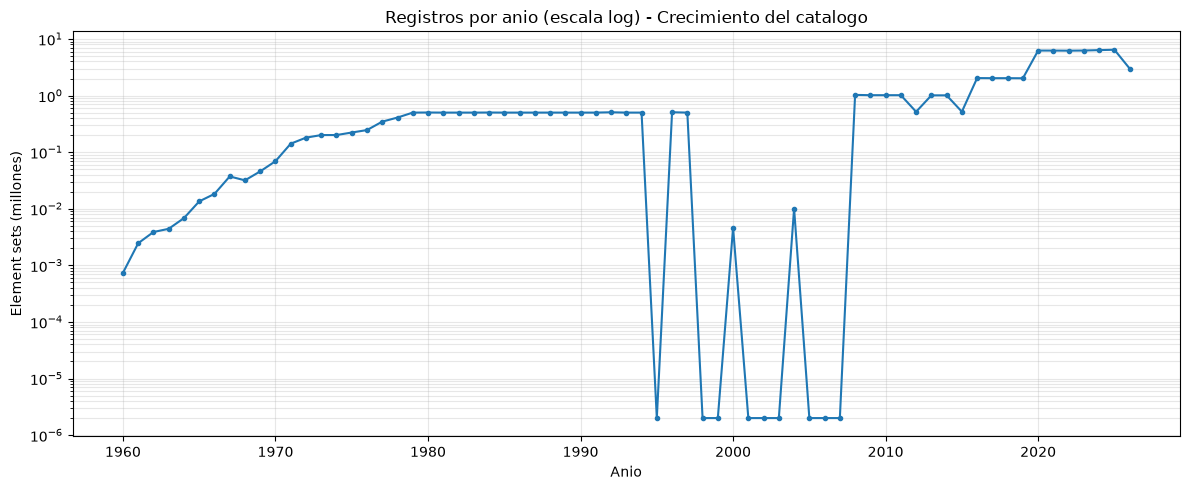

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_rows["anio"], df_rows["filas"] / 1e6, marker="o", ms=3)
ax.set_yscale("log")
ax.set_title("Registros por anio (escala log) - Crecimiento del catalogo")
ax.set_xlabel("Anio")
ax.set_ylabel("Element sets (millones)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


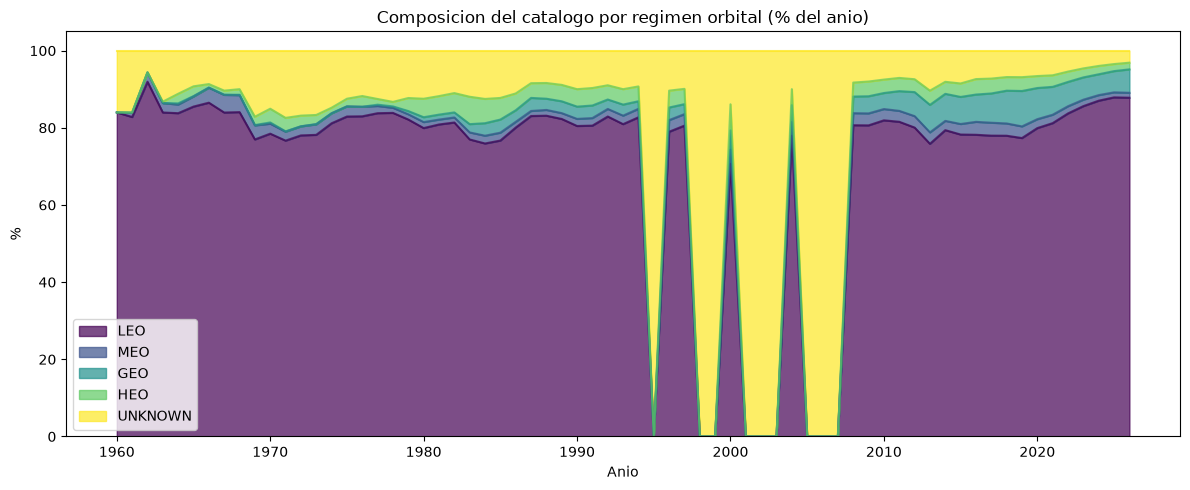

In [15]:
# Evolucion de la participacion de cada regimen orbital.
ax = df_orbit_share.plot(
    kind="area", figsize=(12, 5), colormap="viridis", alpha=0.7
)
ax.set_title("Composicion del catalogo por regimen orbital (% del anio)")
ax.set_ylabel("%")
ax.set_xlabel("Anio")
plt.tight_layout()
plt.show()


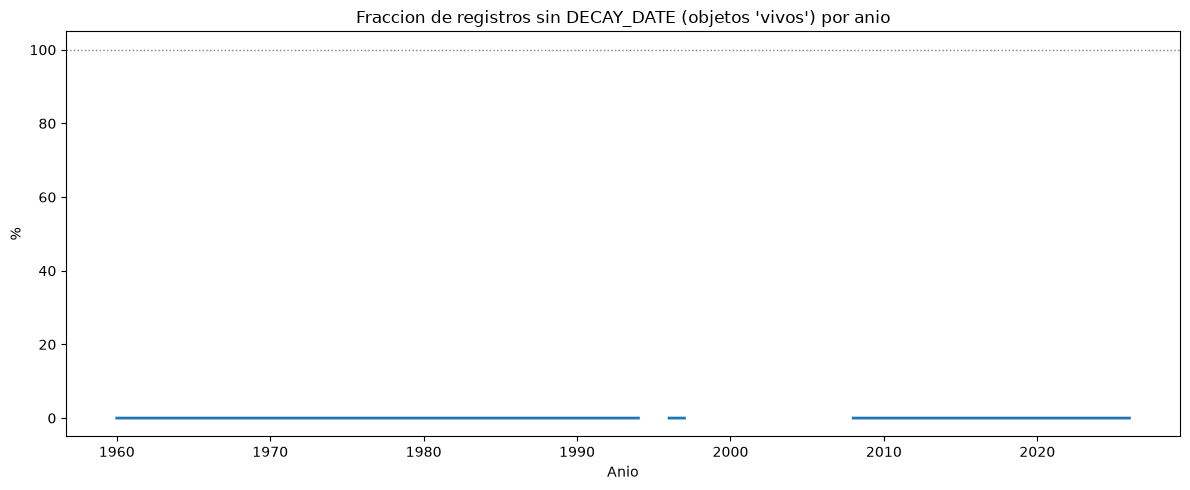

In [16]:
# Objetos activos (sin DECAY_DATE) vs total por anio (muestra).
active_by_year = {}
for year in df_rows["anio"]:
    files_y = [f for f in ALL_FILES if f.split("year=")[1].split(os.sep)[0] == str(year)]
    act = 0
    tot = 0
    for f in files_y:
        df = pq.read_table(f, columns=["DECAY_DATE", "NORAD_CAT_ID"]).to_pandas()
        act += int(df["DECAY_DATE"].isna().sum())
        tot += int(df["NORAD_CAT_ID"].notna().sum())
    active_by_year[year] = (act, tot)

df_act = pd.DataFrame(active_by_year, index=["activos", "total"]).T
df_act["fraccion_activos"] = df_act["activos"] / df_act["total"]

ax = (df_act["fraccion_activos"] * 100).plot(figsize=(12, 5), lw=2)
ax.set_title("Fraccion de registros sin DECAY_DATE (objetos 'vivos') por anio")
ax.set_ylabel("%")
ax.set_xlabel("Anio")
ax.axhline(100, color="gray", ls=":", lw=1)
plt.tight_layout()
plt.show()


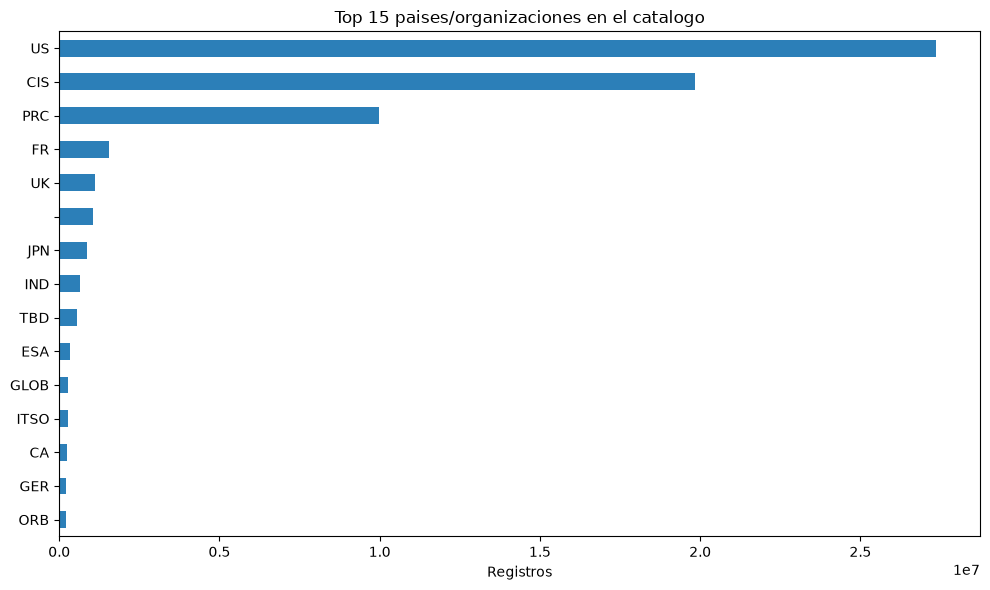

In [17]:
ax = top15_country.plot(kind="barh", figsize=(10, 6), color="#2c7fb8")
ax.set_title("Top 15 paises/organizaciones en el catalogo")
ax.set_xlabel("Registros")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Conclusiones

El notebook confirma que la descarga es:

- **Completa en cobertura temporal** (desde 1960 hasta la fecha, sin huecos).
- **Esquema consistente** en todos los archivos parte.
- **TLE integras** si la validacion de checksum no reporto errores.
- **Coherente con la historia espacial**: el catalogo crece de cientos a
  millones de registros, dominado hoy por satelites LEO (Starlink), con
  US/PRC/CIS como principales operadores y un volumen enorme de debris.

Recomendaciones: para analisis pesados filtrar por columnas proyectadas y
trabajar anio a anio; usar `NORAD_CAT_ID` (+ `GP_ID`) como clave primaria y
`EPOCH` para ordenar temporalmente.
